In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
from xgboost import XGBRegressor

In [5]:
daily_sales = pd.read_csv("../data/forecasting_dataset.csv")

In [6]:
daily_sales.head(10)

,date,sales,lag_1,rolling_mean_7
0,2016-10-04,79,8.0,13.571429
1,2016-10-05,65,79.0,22.571429
2,2016-10-06,60,65.0,31.000000
3,2016-10-07,54,60.0,38.571429
4,2016-10-08,48,54.0,45.000000
5,2016-10-09,36,48.0,50.000000
6,2016-10-10,49,36.0,55.857143
7,2016-10-22,1,49.0,44.714286
8,2016-12-23,1,1.0,35.571429
9,2017-01-05,32,1.0,31.571429


In [7]:
features = ["lag_1", "rolling_mean_7"]

X = daily_sales[features]
y = daily_sales["sales"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [9]:
from xgboost import XGBRegressor

In [10]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

In [11]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
predictions = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [14]:
mae = mean_absolute_error(y_test, predictions)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

In [15]:
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 42.00188446044922
RMSE: 56.165252999797396


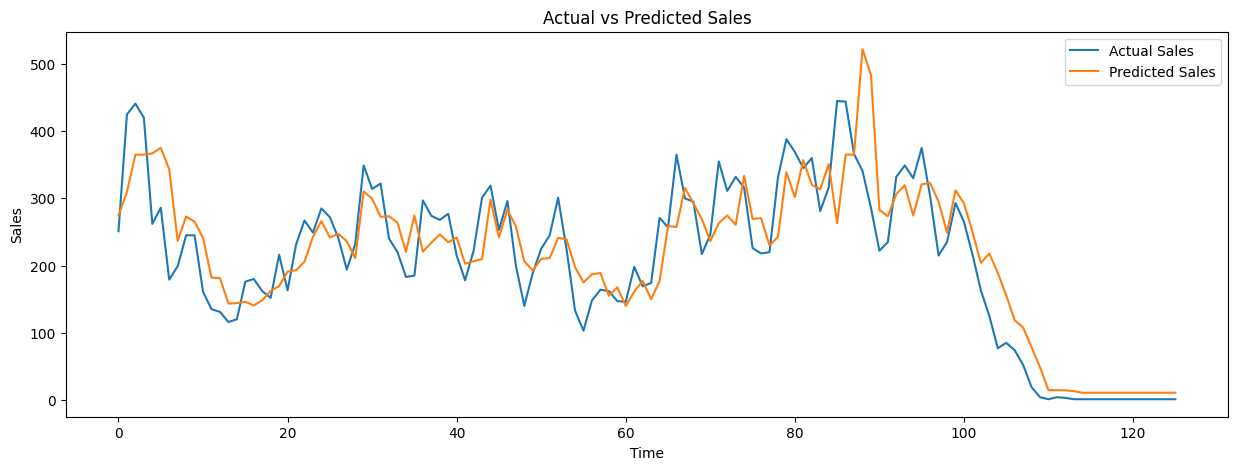

In [16]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    predictions,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [17]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance

,Feature,Importance
0,lag_1,0.183625
1,rolling_mean_7,0.816375


# Save Trained Model

In [18]:
import joblib

In [19]:
joblib.dump(model, "../models/xgboost_model.pkl")

['../models/xgboost_model.pkl']

In [3]:
daily_sales = pd.read_csv("../data/forecasting_dataset.csv")

In [4]:
features = [
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7"
]

In [5]:
X = daily_sales[features]
y = daily_sales["sales"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [7]:
from xgboost import XGBRegressor

model_v2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model_v2.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
predictions_v2 = model_v2.predict(X_test)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_v2 = mean_absolute_error(y_test, predictions_v2)
rmse_v2 = mean_squared_error(y_test, predictions_v2) ** 0.5

print("MAE:", mae_v2)
print("RMSE:", rmse_v2)

MAE: 50.52626037597656
RMSE: 61.35935908454084


In [11]:
import joblib

In [12]:
joblib.dump(model_v2, "../models/xgboost_v2.pkl")

['../models/xgboost_v2.pkl']